In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import logging
import os
import sys
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

import xarray as xr
import xesmf as xe
import numpy as np

In [15]:
def regrid_modis_to_wrf_nearest_timeseries(modis_data, nan=False, reuse_weights=False):
    """
    Regrid MODIS 0/1 snow mask to WRF (curvilinear) grid using nearest-neighbor (2D),
    for multiple time steps.

    Parameters
    ----------
    modis_data : xr.DataArray
        Must include a time dimension (any name) plus 2D spatial dims.
        Must have coords 'lat' and 'lon' (1D or 2D).
        Values: 0/1 (optionally NaN for clouds).
    reuse_weights : bool
        If True, reuse saved weights file.

    Returns
    -------
    xr.Dataset with:
      - snow_mask(time, south_north, west_east) uint8
      - lat(south_north, west_east), lon(south_north, west_east)
    """
    import xesmf as xe
    import xarray as xr
    import numpy as np

    # -----------------------
    # Load WRF template
    # -----------------------
    path_geog_file = "/bsuscratch/stanleyakor/uppercolorado/static_inputs/wrfout_d02_2000-04-08_00:00:00"
    grid_template = xr.open_dataset(path_geog_file)
    LAT = grid_template["XLAT"].isel(Time=0)
    LON = grid_template["XLONG"].isel(Time=0)

    # Target grid 
    target_grid = xr.Dataset(
        {"lat": (LAT.dims, LAT.values),
         "lon": (LON.dims, LON.values)}
    )

    # -----------------------
    # Validate MODIS coords
    # -----------------------
    if "lat" not in modis_data.coords or "lon" not in modis_data.coords:
        raise ValueError("modis_data must have 'lat' and 'lon' coordinates (1D or 2D).")

    # -----------------------
    # Identify dims: time vs spatial
    # -----------------------
    # Assume time dim is any dim not equal to the 2 spatial dims.
    # Prefer standard names if present.
    candidate_time = [d for d in modis_data.dims if d.lower() in ("time", "xtime", "t")]
    if candidate_time:
        tdim = candidate_time[0]
    else:
        # fallback: first dim that is not lat/lon dims (common: time,y,x)
        tdim = None
        for d in modis_data.dims:
            if d not in ("lat", "lon"):
                tdim = d
                break

    # Determine spatial dims from the DataArray (excluding time dim if present)
    spatial_dims = [d for d in modis_data.dims if d != tdim]
    if len(spatial_dims) != 2:
        raise ValueError(
            f"Expected 2 spatial dims (plus optional time), got dims={modis_data.dims}. "
            "Make sure modis_data is (time, y, x) or (y, x)."
        )
    ydim, xdim = spatial_dims

    
    if modis_data["lat"].ndim == 1:
        # lat is along y-like axis, ensure it increases
        
        if float(modis_data["lat"].diff("lat").mean()) < 0:
            modis_data = modis_data.sortby("lat")
    else:
        # 2D lat: check trend down first column
        lat_profile = modis_data["lat"].isel({xdim: 0})
        if float(lat_profile.diff(ydim).mean()) < 0:
            modis_data = modis_data.isel({ydim: slice(None, None, -1)})

    # -----------------------
    # Build explicit MODIS source grid (2D)
    # -----------------------
    if modis_data["lat"].ndim == 1 and modis_data["lon"].ndim == 1:
        lon2, lat2 = xr.broadcast(modis_data["lon"], modis_data["lat"])
        source_grid = xr.Dataset({"lat": lat2, "lon": lon2})
    else:
        source_grid = xr.Dataset({"lat": modis_data["lat"], "lon": modis_data["lon"]})

    # -----------------------
    # Build regridder once, apply to all timesteps
    # -----------------------
    regridder = xe.Regridder(
        source_grid,
        target_grid,
        method="nearest_s2d",
        periodic=False,
        ignore_degenerate=True,
        filename="modis_to_wrf_weights_nearest_s2d.nc",
        reuse_weights=reuse_weights,
    )


    modis_nn = regridder(modis_data)

    # Keep binary semantics; nearest should already be 0/1, but this is safe.
    snow_mask = xr.where(modis_nn >= 0.5, 1, 0).astype(np.uint8)
    snow_mask.name = "snow_mask"

    # Coverage per timestep (optional summary print)
    if tdim is not None and tdim in snow_mask.dims:
        snow_pct_ts = (snow_mask == 1).mean(dim=(LAT.dims[0], LAT.dims[1])) * 100.0
        print(f"Snow coverage range: {float(snow_pct_ts.min()):.1f}% – {float(snow_pct_ts.max()):.1f}%")
    else:
        snow_pct = float((snow_mask == 1).sum().values / snow_mask.size * 100.0)
        print(f"Snow coverage: {snow_pct:.1f}%")

    # -----------------------
    # Return Dataset on WRF grid
    # -----------------------
    # Ensure output dims are (time, south_north, west_east) if time exists
    out_coords = {"lat": (LAT.dims, LAT.values), "lon": (LON.dims, LON.values)}
    if tdim is not None and tdim in modis_data.coords:
        out_coords[tdim] = modis_data[tdim]

    ds_out = xr.Dataset(
        data_vars={"snow_mask": snow_mask},
        coords=out_coords,
        attrs={
            "description": "MODIS snow mask regridded to WRF grid using xESMF nearest_s2d (timeseries)",
            "regridding_method": "nearest_s2d",
            "snow_threshold": 0.5,
            "wrf_template": path_geog_file,
        },
    )

    ds_out["snow_mask"].attrs.update(
        {"long_name": "Snow mask on WRF grid", "values": "0=no snow, 1=snow", "source": "MODIS"}
    )

    return ds_out


In [11]:
# file_paths = []
# for i in range(3,18):
#     if i < 10:i = f'0{i}'
#     file_paths.append(f'/bsuscratch/stanleyakor/nscid/wy/wy20{i}/full_corrected_snow_data_wy20{i}.nc')
# file_paths

In [12]:
# concate data
# x = xr.open_mfdataset(file_paths, concat_dim='time', combine='nested', parallel=True)

In [5]:
# np.unique(x['snow_mask'].values.flatten())

In [6]:
# regridded_x = regrid_modis_to_wrf_nearest_timeseries(x['snow_mask'])

# regridded_x = regridded_x.rename_dims({'time': 'XTIME'})

#regridded_x.to_netcdf('../data/modis_snow_cover.nc')

In [7]:
# Explore data

In [8]:
ds = xr.open_dataset('../data/modis_snow_cover.nc')

getfattr: /bsuscratch/stanleyakor/nscid/data/modis_snow_cover.nc: Operation not supported


In [9]:
ds['XTIME'] = xr.decode_cf(ds).XTIME  
ds['time'] = xr.DataArray(pd.to_datetime(ds['XTIME'].values), dims='XTIME')
ds = ds.swap_dims({'XTIME': 'time'})  

In [10]:
monthly_climatology = ds['snow_mask'].groupby('time.month').mean(dim='time') 

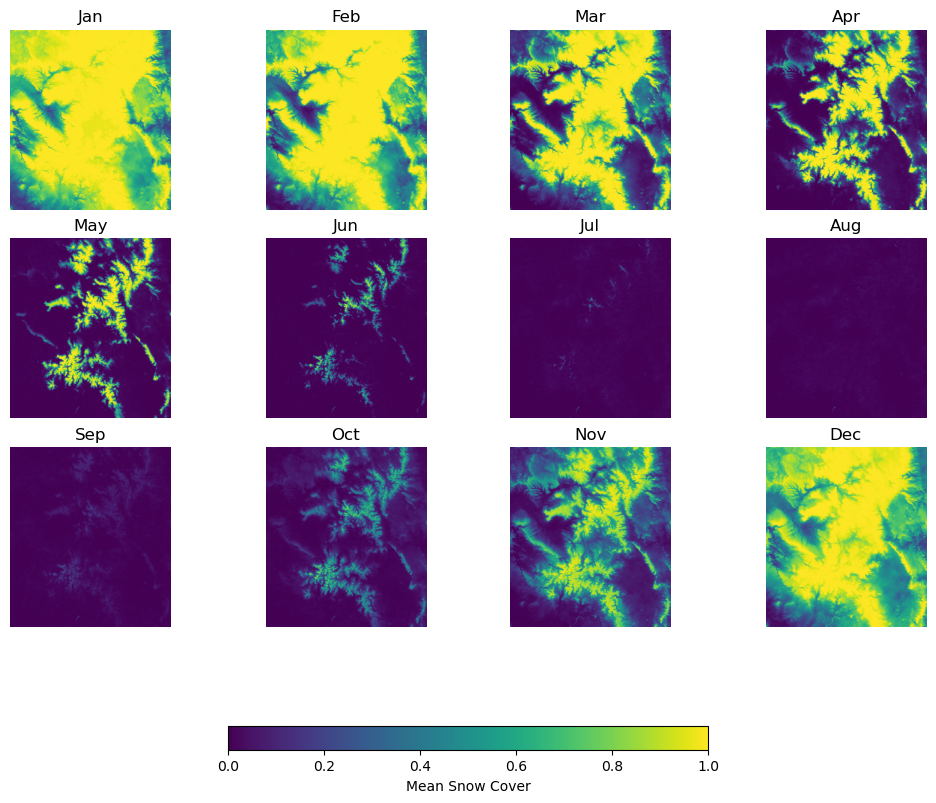

In [11]:
red_white_cmap = 'viridis'



fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 8), constrained_layout=True)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, ax in enumerate(axes.flat):
    im = ax.imshow(monthly_climatology[i, :, :], cmap=red_white_cmap, vmin=0, vmax=1, origin = 'lower')
    ax.set_title(months[i])
    ax.axis('off')


cbar = fig.colorbar(
    im, ax=axes[:, 1:3], orientation='horizontal', fraction=0.08, pad=0.15
)

cbar.set_label('Mean Snow Cover')
plt.show()